In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import missingno as msno

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

In [2]:
file_path = '../data/raw/Credit Score Classification Dataset/train.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Data Shape: {df.shape}")
    display(df.head())
    display(df.info())
except FileNotFoundError:
    print("Error: File not found. Check the exact filename in your directory.")

Data Shape: (100000, 28)


C:\Users\user\AppData\Local\Temp\ipykernel_20120\1225567155.py:4: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  str    
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

None

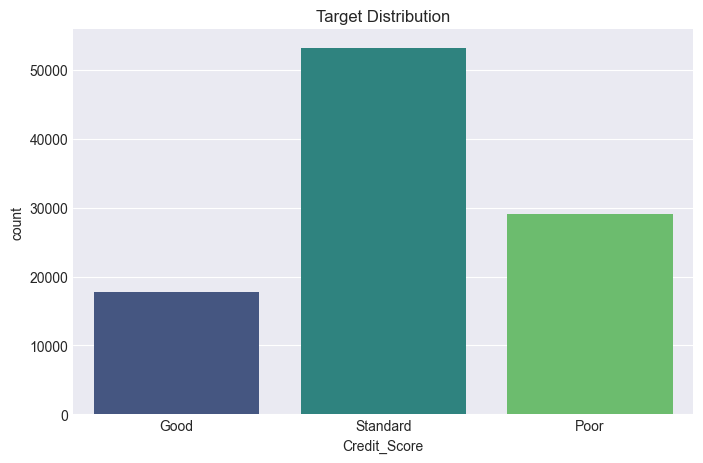

--- Target Class Proportions (%) ---
Credit_Score
Standard    53.174
Poor        28.998
Good        17.828
Name: proportion, dtype: float64


In [3]:
target_col = 'Credit_Score'

if target_col in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    plt_sns.countplot(data=df, x=target_col, ax=ax, hue=target_col, palette='viridis', legend=False)
    plt.title('Target Distribution')
    plt.savefig("target_distribution", dpi=300, bbox_inches="tight")
    plt.show()
    
    print("--- Target Class Proportions (%) ---")
    print(df[target_col].value_counts(normalize=True) * 100)
else:
    print(f"Error: Target column '{target_col}' not found. Verify the column names in df.head().")

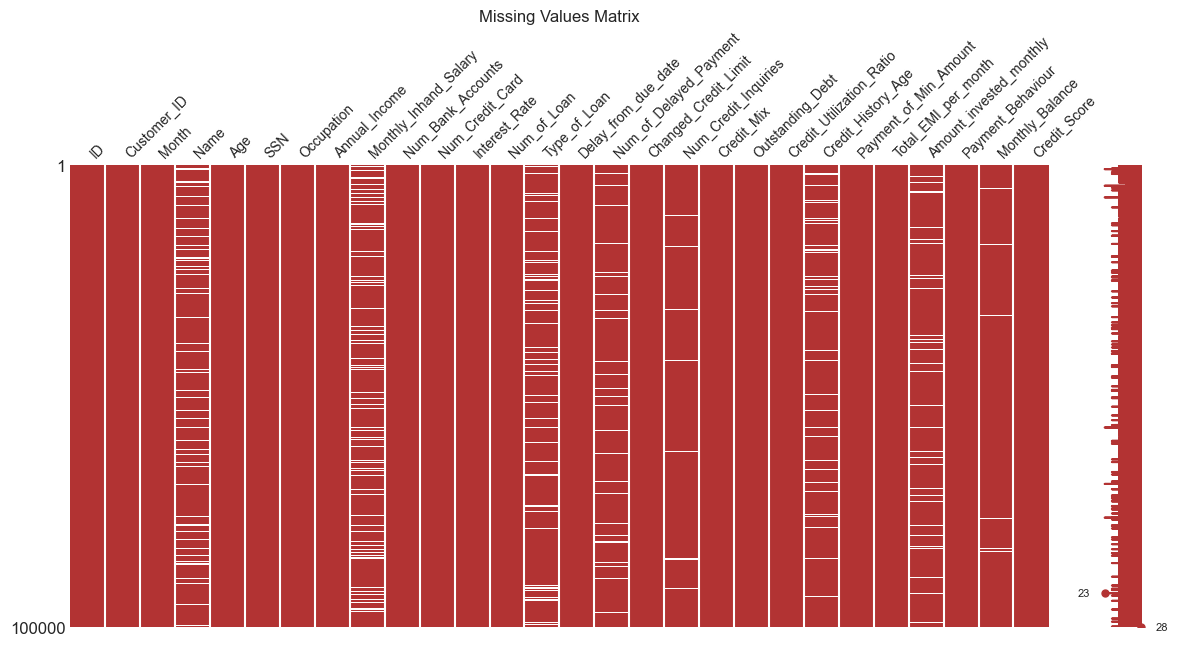

In [4]:
msno.matrix(df, figsize=(14, 6), fontsize=10, color=(0.7, 0.2, 0.2))
plt.title('Missing Values Matrix')
plt.savefig("missing_value_matrix", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
drop_cols = ['ID', 'Customer_ID', 'Month', 'Name', 'SSN']

cat_cols_raw = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols_raw if col not in drop_cols and col != target_col]

num_but_str = ['Age', 'Annual_Income', 'Num_of_Loan', 'Delay_from_due_date', 
               'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 
               'Credit_History_Age', 'Amount_invested_monthly', 'Monthly_Balance']

pure_cat_cols = [col for col in cat_cols if col not in num_but_str]

print("--- Pure Categorical Features for Cramer's V ---")
print(pure_cat_cols)

--- Pure Categorical Features for Cramer's V ---
['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


C:\Users\user\AppData\Local\Temp\ipykernel_20120\818930053.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_raw = df.select_dtypes(include=['object']).columns.tolist()


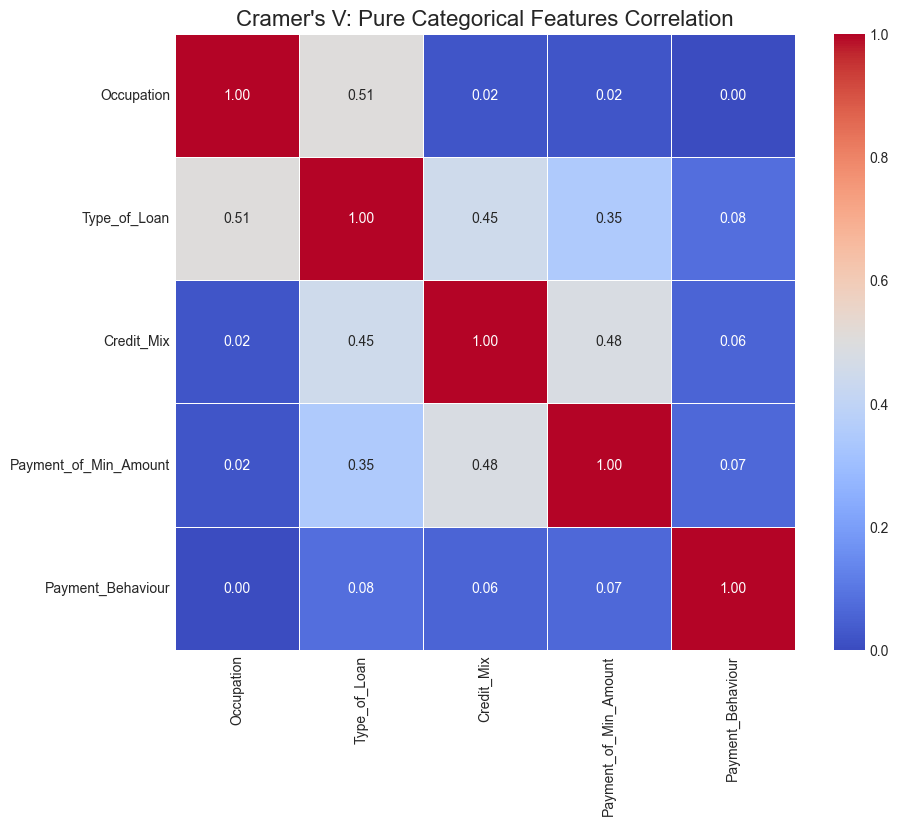

--- High Correlation Pairs (> 0.5) ---


,Feature_1,Feature_2,Correlation
1,Occupation,Type_of_Loan,0.505125
5,Type_of_Loan,Occupation,0.505125


In [6]:
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

df_sample = df.sample(n=20000, random_state=42).copy()

df_sample['Target_Binary'] = df_sample[target_col].apply(lambda x: 1 if x == 'Poor' else 0)

cramer_matrix = pd.DataFrame(index=pure_cat_cols, columns=pure_cat_cols)

for col1 in pure_cat_cols:
    for col2 in pure_cat_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df_sample[col1], df_sample[col2])

cramer_matrix = cramer_matrix.astype(float)

plt.figure(figsize=(10, 8))
plt_sns.heatmap(cramer_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Cramer's V: Pure Categorical Features Correlation", fontsize=16)
plt.savefig("cat_feat_corr", dpi=300, bbox_inches="tight")
plt.show()

print("--- High Correlation Pairs (> 0.5) ---")
high_corr = cramer_matrix[cramer_matrix > 0.5].stack().reset_index()
high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']
high_corr = high_corr[high_corr['Feature_1'] != high_corr['Feature_2']].drop_duplicates()
display(high_corr.dropna())

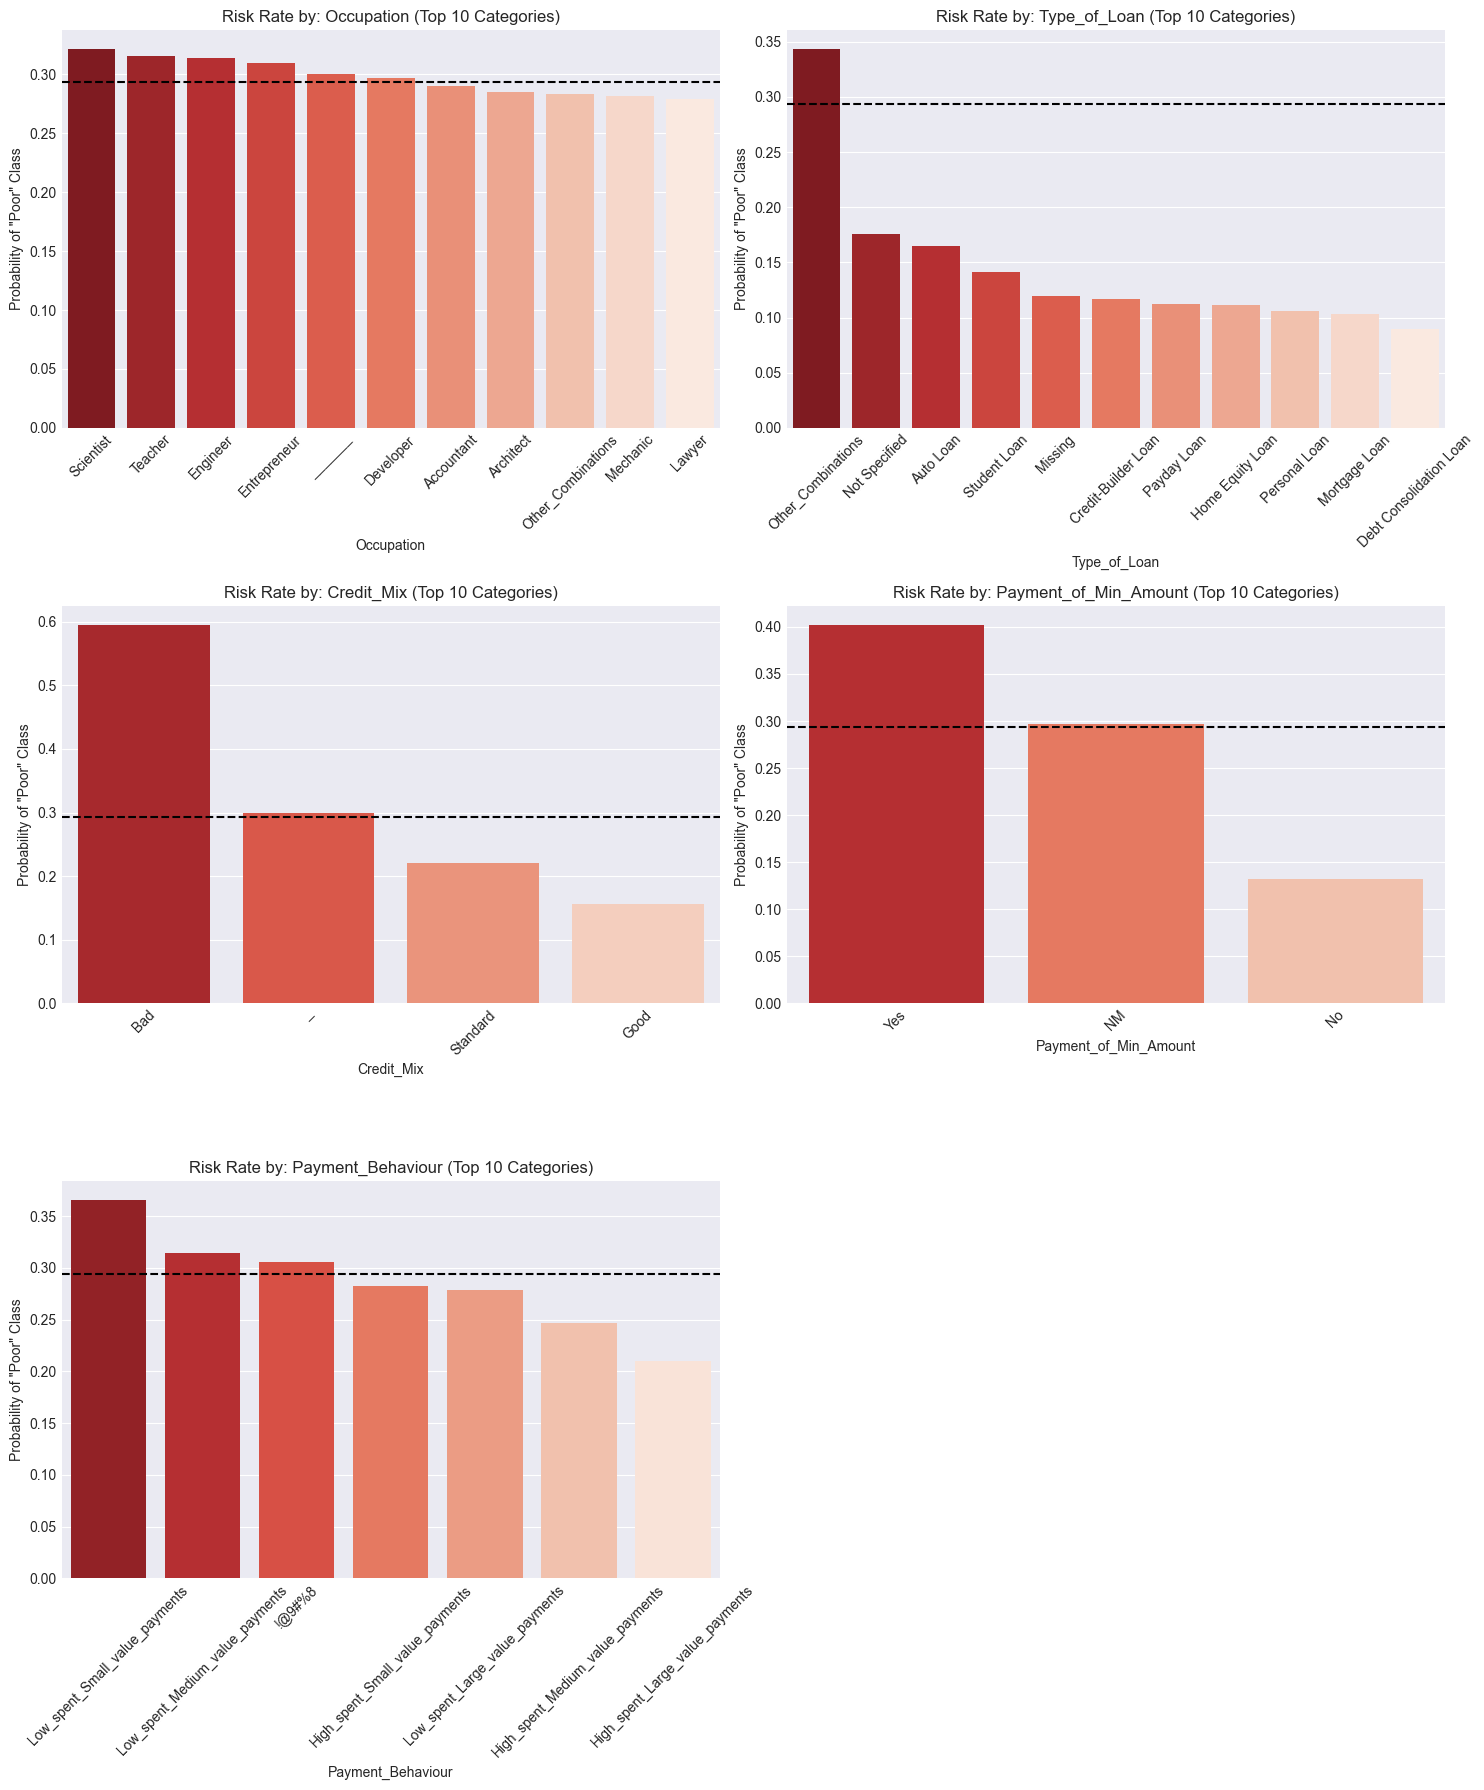

--- VISUALIZATION FIXED ---
Applied Top-10 frequency filter to handle high cardinality columns.


In [10]:
num_plots = len(pure_cat_cols)
cols_per_row = 2
rows = int(np.ceil(num_plots / cols_per_row))

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 6 * rows))
axes = axes.flatten()

global_mean = df_sample['Target_Binary'].mean()

for i, col in enumerate(pure_cat_cols):
    series_clean = df_sample[col].fillna('Missing').astype(str)
    
    top_categories = series_clean.value_counts().nlargest(10).index
    series_filtered = series_clean.apply(lambda x: x if x in top_categories else 'Other_Combinations')
    
    risk_table = df_sample['Target_Binary'].groupby(series_filtered).mean().sort_values(ascending=False)
    
    plt_sns.barplot(x=risk_table.index, y=risk_table.values, ax=axes[i], hue=risk_table.index, palette='Reds_r', legend=False)
    axes[i].set_title(f'Risk Rate by: {col} (Top 10 Categories)', fontsize=12)
    axes[i].set_ylabel('Probability of "Poor" Class')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(global_mean, color='black', linestyle='--', label='Global Average')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("risk_rate.png", dpi=150, bbox_inches="tight")
plt.show()

print("--- VISUALIZATION FIXED ---")
print("Applied Top-10 frequency filter to handle high cardinality columns.")